In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,confusion_matrix,ConfusionMatrixDisplay


In [4]:
from google.colab import files
uploaded=files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads.csv


In [6]:
df=pd.read_csv("Social_Network_Ads.csv")

In [7]:
print(df)

      User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]


In [8]:
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [10]:
print(df.isnull().sum())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [11]:
print(df.describe())

            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [12]:
df.drop("User ID",axis=1)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [20]:
X=df[["Age","EstimatedSalary"]]
y=df["Purchased"]

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
#Standardized the data
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [30]:
#Now we have to find the best value for our model
k_values=range=[1,21]
cv_score=[]
for k in k_values:
  knn=KNeighborsClassifier(n_neighbors=k)
  scores=cross_val_score(knn,X_train_scaled,y_train,cv=5,scoring="accuracy")
  cv_score.append(scores.mean())

print(scores)



[0.90625  0.953125 0.90625  0.875    0.84375 ]


In [32]:
for k, score in zip(k_values, cv_score):
    print(f"K = {k}, CV Accuracy = {score:.4f}")

K = 1, CV Accuracy = 0.8500
K = 21, CV Accuracy = 0.8969


In [38]:
best_score = max(cv_score)

best_k = list(k_values)[cv_score.index(best_score)]

print("Best K:", best_k)
print("Best Cross-Validation Accuracy:", best_score)

Best K: 21
Best Cross-Validation Accuracy: 0.896875


In [41]:
final_model=KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled,y_train)
y_pred=final_model.predict(X_test_scaled)
print(y_pred)

[1 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 0
 1 0 1 1 0 0]


In [42]:
results=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

In [43]:
print(results)

     Actual  Predicted
209       0          1
280       1          1
33        0          0
210       1          1
93        0          0
..      ...        ...
246       0          0
227       1          1
369       1          1
176       0          0
289       1          0

[80 rows x 2 columns]


In [44]:
print(results.shape)

(80, 2)


In [45]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Final Test Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Final Test Accuracy: 0.925
Accuracy Percentage: 92.5 %


In [48]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[48  4]
 [ 2 26]]


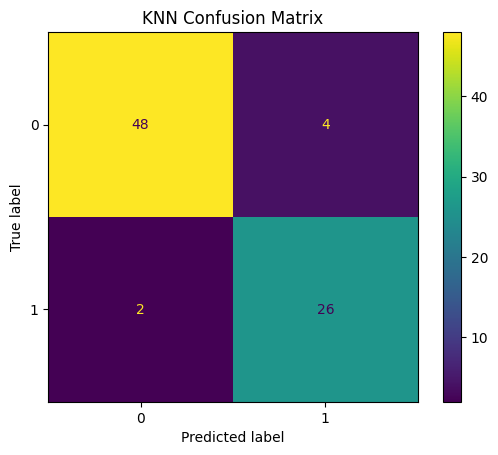

In [52]:
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("KNN Confusion Matrix")
plt.show()

In [54]:
new_customer = pd.DataFrame(
    [[30, 87000]],
    columns=["Age", "EstimatedSalary"]
)

In [55]:
new_customer_scaled = scaler.transform(
    new_customer
)

In [57]:
prediction = final_model.predict(
    new_customer_scaled
)

print(prediction)

[0]


In [58]:
if prediction[0] == 1:
    print("Customer is likely to purchase the product.")
else:
    print("Customer is not likely to purchase the product.")

Customer is not likely to purchase the product.
